## makemore: part 5 (building a WaveNet)

[DeepMind blog post from 2016](https://www.deepmind.com/blog/wavenet-a-generative-model-for-raw-audio)

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [2]:
# download the names.txt file from github
!wget https://raw.githubusercontent.com/karpathy/makemore/master/names.txt

zsh:1: command not found: wget


In [3]:
# read in all the words
words = open('isimler.txt', 'r').read().splitlines()
print(len(words))
print(max(len(w) for w in words))
print(words[:8])

2447
18
['DORA', 'JALE', 'ALİ', 'MAHMUT', 'MANSUR KÜRŞAD', 'GAMZE', 'MİRAÇ', 'YÜCEL']


In [4]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: ' ', 2: '!', 3: 'A', 4: 'B', 5: 'C', 6: 'D', 7: 'E', 8: 'F', 9: 'G', 10: 'H', 11: 'I', 12: 'J', 13: 'K', 14: 'L', 15: 'M', 16: 'N', 17: 'O', 18: 'P', 19: 'R', 20: 'S', 21: 'T', 22: 'U', 23: 'V', 24: 'Y', 25: 'Z', 26: 'Ç', 27: 'Ö', 28: 'Ü', 29: 'Ğ', 30: 'İ', 31: 'Ş', 0: '.'}
32


In [5]:
# shuffle up the words
import random
random.seed(42)
random.shuffle(words)

In [6]:
# build the dataset
block_size = 8 # context length: how many characters do we take to predict the next one?

def build_dataset(words):
  X, Y = [], []

  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([14509, 8]) torch.Size([14509])
torch.Size([1831, 8]) torch.Size([1831])
torch.Size([1777, 8]) torch.Size([1777])


In [7]:
for x,y in zip(Xtr[:20], Ytr[:20]):
  print(''.join(itos[ix.item()] for ix in x), '-->', itos[y.item()])

........ --> D
.......D --> O
......DO --> Ğ
.....DOĞ --> A
....DOĞA --> N
...DOĞAN --> .
........ --> S
.......S --> E
......SE --> N
.....SEN --> A
....SENA --> N
...SENAN --> .
........ --> A
.......A --> K
......AK --> I
.....AKI --> N
....AKIN --> .
........ --> B
.......B --> U
......BU --> R


In [8]:
# Near copy paste of the layers we have developed in Part 3

# -----------------------------------------------------------------------------------------------
class Linear:

  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5 # note: kaiming init
    self.bias = torch.zeros(fan_out) if bias else None

  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out

  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])

# -----------------------------------------------------------------------------------------------
class BatchNorm1d:

  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training = True
    # parameters (trained with backprop)
    self.gamma = torch.ones(dim) #bngain, başlangıçta 1, stdi
    self.beta = torch.zeros(dim) #bngain, başlangıçta 0, mean
    # buffers (trained with a running 'momentum update')
    self.running_mean = torch.zeros(dim) #bnmean_running
    self.running_var = torch.ones(dim) #bnstd_running gibi ama std yerine variance tutuluyor. bunlar samplingde lazım usttekıyle bu.

  def __call__(self, x):
    # calculate the forward pass
    if self.training:
      if x.ndim == 2:
        dim = 0
      elif x.ndim == 3:
        dim = (0,1)
      xmean = x.mean(dim, keepdim=True) # batch mean
      xvar = x.var(dim, keepdim=True) # batch variance
    else:
      xmean = self.running_mean
      xvar = self.running_var
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
    self.out = self.gamma * xhat + self.beta
    # update the buffers
    if self.training:
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
    return self.out

  def parameters(self):
    return [self.gamma, self.beta]

# -----------------------------------------------------------------------------------------------
class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out
  def parameters(self):
    return []

# -----------------------------------------------------------------------------------------------
class Embedding:

  def __init__(self, num_embeddings, embedding_dim):
    self.weight = torch.randn((num_embeddings, embedding_dim)) #C

  def __call__(self, IX):
    self.out = self.weight[IX]
    return self.out

  def parameters(self):
    return [self.weight]

# # -----------------------------------------------------------------------------------------------
class FlattenConsecutive:

  def __init__(self, n):
    self.n = n

  def __call__(self, x):
    B, T, C = x.shape
    x = x.view(B, T//self.n, C*self.n)
    if x.shape[1] == 1:
      x = x.squeeze(1)
    self.out = x
    return self.out

  def parameters(self):
    return []

# # -----------------------------------------------------------------------------------------------
class Sequential:

  def __init__(self, layers):
    self.layers = layers

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    self.out = x
    return self.out

  def parameters(self):
    # get parameters of all layers and stretch them out into one list
    return [p for layer in self.layers for p in layer.parameters()]


In [9]:
torch.manual_seed(42); # seed rng for reproducibility

In [10]:
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 64 # the number of neurons in the hidden layer of the MLP

model = Sequential([
  Embedding(vocab_size, n_embd), # embed the characters into vectors
  FlattenConsecutive(2), Linear(n_embd * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(n_hidden, vocab_size, bias=False),
])

# # parameter init
# with torch.no_grad():
#   layers[-1].weight *= 0.1 # last layer make less confident

parameters = model.parameters()
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

20416


In [11]:
logits = model(Xtr[:4])   # bunu ekle
for layer in model.layers:
    print(layer.__class__.__name__, ':', tuple(layer.out.shape))

Embedding : (4, 8, 10)
FlattenConsecutive : (4, 4, 20)
Linear : (4, 4, 64)
BatchNorm1d : (4, 4, 64)
Tanh : (4, 4, 64)
FlattenConsecutive : (4, 2, 128)
Linear : (4, 2, 64)
BatchNorm1d : (4, 2, 64)
Tanh : (4, 2, 64)
FlattenConsecutive : (4, 128)
Linear : (4, 64)
BatchNorm1d : (4, 64)
Tanh : (4, 64)
Linear : (4, 32)


In [12]:
#(1, 2,) (3, 4,) (5, 6,) (7, 8,) şeklinde gruplamak istiyoruz

In [13]:
# same optimization as last time
max_steps = 5000
batch_size = 32
lossi = []

for i in range(max_steps):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,))
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

  # forward pass
  logits = model(Xb)
  loss = F.cross_entropy(logits, Yb) #loss

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update: simple SGD
  lr = 0.1 if i < 150000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 1000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item()) 
  
#   log10 neden var, hatırlatma
# loss.log10() — çünkü loss başta hızlı düşüp sonra çok yavaşlıyor (3.3'ten 1.9'a). Normal eksende bu, başlangıcın grafiği ezmesine sebep olurdu. Log ölçek, düşüşü daha okunabilir bir şekilde eşit aralıklı gösteriyor.
  # break

      0/   5000: 3.6222
   1000/   5000: 1.9979
   2000/   5000: 1.6983
   3000/   5000: 1.3383
   4000/   5000: 1.5113


In [14]:
# 1. Xb          [32, 3]      girdi: 32 örnek, her biri 3 harf indeksi

# 2. emb         [32, 3, 10]  her indeks → embedding vektörüne çevrildi (C[Xb])

# 3. embcat      [32, 30]     3 harfin vektörleri yan yana dizildi (view)

# 4. hprebn      [32, 200]    embcat @ W1 + b1 → ham matris çarpımı sonucu

# 5. bnmean      [1, 200]     hprebn.mean(0) → batch ortalaması

# 6. bnvar       [1, 200]     hprebn.var(0) → batch varyansı

# 7. bnraw       [32, 200]    (hprebn - bnmean) / √(bnvar + eps) → tam normalize. (epsilon da şeyden var bi şekil varyans 0 çıkarsa 0 a bölme olmayacağı için hata almayalım diye.)

# 8. hpreact     [32, 200]    bngain * bnraw + bnbias → öğrenilebilir ölçek/kaydırma. (her zaman mean 0,std 1 olacak hali yok en verimli olması için, o yüzden bngain ve bnbias da öğrenilebilir oarametreler. bngain std'yi, bnbias mean'i ayarlıyor.)

# 9. h           [32, 200]    tanh(hpreact) → -1,1 arası, gizli katman çıktısı

# 10. logits     [32, 27]     h @ W2 + b2 → 27 harfin ham skoru. bizim istediğimiz dağılım 27 çıktılı olmalı her bir harf için, o yüzden 200 değil 27 çıktıya çeviriyoruz tensoru. ve bu da bir linear katman (weightlerin çarpıldığı ve bias eklenen bir katman yani, matsal olarak da dogrusal oldugu icin böyle deniyor.)

# 11. loss       tek sayı     F.cross_entropy(logits, Yb) → softmax + NLL, tek satırda


# Zincir: girdi → embedding → düzleştir → Linear → BatchNorm → tanh → Linear → softmax/loss

In [15]:
lossi[:10] #lossi şu anda bir liste her adımdaki lossu tutan.

[0.5589696764945984,
 0.5552037358283997,
 0.5524224042892456,
 0.5196657180786133,
 0.5327537059783936,
 0.5479243993759155,
 0.5163702368736267,
 0.5271504521369934,
 0.5227503776550293,
 0.507056713104248]

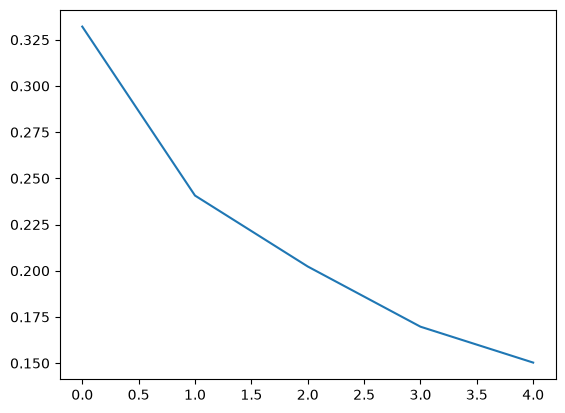

In [16]:
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1)) #yaptığımız şey aslında lossi listesini BİNERLİ (1000) ayırıp her 1000 lik grubun ortalamasını aldık böylece anlık dalgalanmaları değil genel eğilimi gördük which is loss düşüyor.

In [17]:
# put layers into eval mode (needed for batchnorm especially)
for layer in model.layers:
  layer.training = False

In [18]:
# evaluate the loss
@torch.no_grad() # this decorator disables gradient tracking inside pytorch
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  logits = model(x)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.369132161140442
val 1.634493112564087


### performance log

- original (3 character context + 200 hidden neurons, 12K params): train 2.058, val 2.105
- context: 3 -> 8 (22K params): train 1.918, val 2.027
- flat -> hierarchical (22K params): train 1.941, val 2.029
- fix bug in batchnorm: train 1.912, val 2.022
- scale up the network: n_embd 24, n_hidden 128 (76K params): train 1.769, val 1.993


In [21]:
# sample from the model
for _ in range(20):

    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # forward pass the neural net
      logits = model(torch.tensor([context]))
      probs = F.softmax(logits, dim=1)
      # sample from the distribution
      ix = torch.multinomial(probs, num_samples=1).item()
      # shift the context window and track the samples
      context = context[1:] + [ix]
      out.append(ix)
      # if we sample the special '.' token, break
      if ix == 0:
        break

    print(''.join(itos[i] for i in out)) # decode and print the generated word

SMAHAN.
MUSTAFA.
RÖZRAN.
MEHMET.
FUNAN.
ERDEM.
MUSTAFA.
ŞERİFE.
MÜHADİ YIZAN.
GÜLŞASİN.
MURAT.
MERRİ.
NİRİME SOİ.
YUSUN.
REMAN.
MERVE.
ALPEĞ.
ELİF.
MERZUN.
PINGÜN.
